In [ ]:
import zipfile
import os
import psutil
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model

import pickle

import warnings
warnings.filterwarnings("ignore")

2025-11-22 18:55:38.096214: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 18:55:38.221264: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-22 18:55:53.289195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-22 18:56:00.599188: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [6]:
# Extraer el archivo .zip

with zipfile.ZipFile("../data/raw/dogs-vs-cats.zip", 'r') as zip_ref:
    zip_ref.extractall("../data/raw/dataset")

In [ ]:
# Paths
raw_path = "../data/raw/dataset/dogs-vs-cats/train"

traintest_path = "../data/processed"

train_path = "../data/processed/train"
test_path = "../data/processed/test"

train_cats_path = "../data/processed/train/cats"
train_dogs_path = "../data/processed/train/dogs"
test_cats_path = "../data/processed/test/cats"
test_dogs_path = "../data/processed/test/dogs"

Esto crea la carpeta /dataset/ con dentro /train/ que contiene todas las imágenes

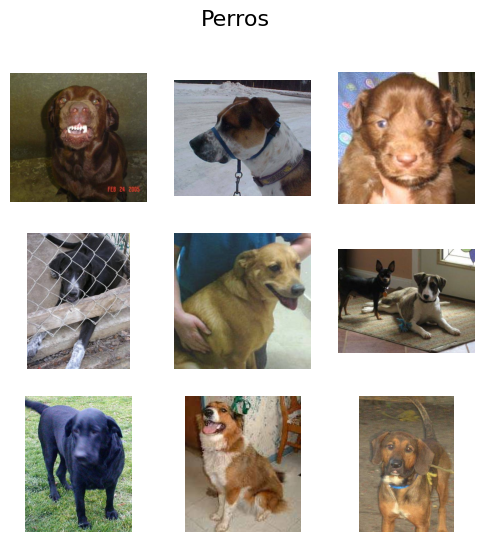

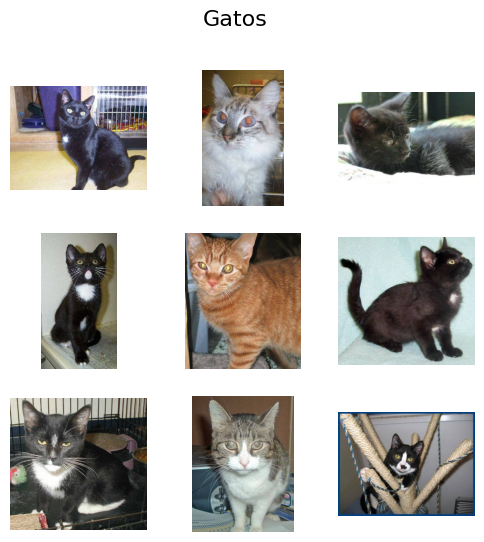

In [ ]:
# Visualizar 9 imagenes de perros y gatos

def show_images(file_list, raw_path, title):
    plt.figure(figsize=(6,6))
    for i, f in enumerate(file_list):
        img_path = os.path.join(raw_path, f)
        img = image.load_img(img_path)       
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show

dog_images = [f for f in os.listdir(raw_path) if f.startswith("dog")][:9]     # Busca los archivos que empiezan por "dog"
cat_images = [f for f in os.listdir(raw_path) if f.startswith("cat")][:9]     # o "cat" y coge los primeros 9 de cada clase.

# 9 perros
show_images(dog_images, raw_path, "Perros")

# 9 gatos
show_images(cat_images, raw_path, "Gatos")

In [ ]:
# Comprobamos cuántos GB de RAM tenemos

ram_bytes = psutil.virtual_memory().total
ram_gb = ram_bytes / (1024**3)
print(f"Tienes {ram_gb:.2f} GB de RAM")

Tienes 7.76 GB de RAM


Como **no** tengo más de **12 gigabytes de RAM**, cargaremos las imágenes progresivamente usando la clase Keras **ImageDataGenerator** y la función **flow_from_directory()**. Esta función prefiere que los datos se dividan en directorios train y test separados, y debajo de cada directorio para tener un subdirectorio para cada clase

In [ ]:
 # carpeta donde organizamos train y test

for split in ["train", "test"]:
    for cls in ["cats", "dogs"]:
        os.makedirs(os.path.join(traintest_path, split, cls), exist_ok=True)

Hemos creado las carpetas:

../data/processed/train/cats

../data/processed/train/dogs

../data/processed/test/cats

../data/processed/test/dogs

In [ ]:
# Separar los nombres de archivos por cats o dogs

cats = [f for f in os.listdir(raw_path) if f.startswith("cat")]   # Crea una lista de archivos que tienen 'cat' en el nombre.
dogs = [f for f in os.listdir(raw_path) if f.startswith("dog")]   # Crea una lista de archivos que tienen 'dog' en el nombre.

# Dividir en train/test con sklearn
cats_train, cats_test = train_test_split(cats, train_size=0.8, random_state=42)
dogs_train, dogs_test = train_test_split(dogs, train_size=0.8, random_state=42)

# Copiar gatos a carpetas de train y test  
for f in cats_train:
    shutil.copy(os.path.join(raw_path, f), train_cats_path)
for f in cats_test:
    shutil.copy(os.path.join(raw_path, f), test_cats_path)

# Copiar perros a carpetas de train y test
for f in dogs_train:
    shutil.copy(os.path.join(raw_path, f), train_dogs_path)
for f in dogs_test:
    shutil.copy(os.path.join(raw_path, f), test_dogs_path)

In [ ]:
# Generador para train y test
train_datagen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2)

test_datagen = ImageDataGenerator(rescale=1/255)

In [ ]:
# Cargar imágenes desde las carpetas

trdata = train_datagen.flow_from_directory(
    train_path,
    target_size=(200, 200),     # redimensionar las imagenes
    batch_size=32,
    class_mode="binary",
    subset="training"
)

valdata =train_datagen.flow_from_directory(
    train_path,
    target_size=(200,200),
    batch_size=32,
    class_mode="binary",
    subset="validation"
    
)

tsdata = test_datagen.flow_from_directory(
    test_path,
    target_size=(200, 200),
    batch_size=32,
    class_mode="binary"
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [6]:
print(trdata.class_indices)

{'cats': 0, 'dogs': 1}


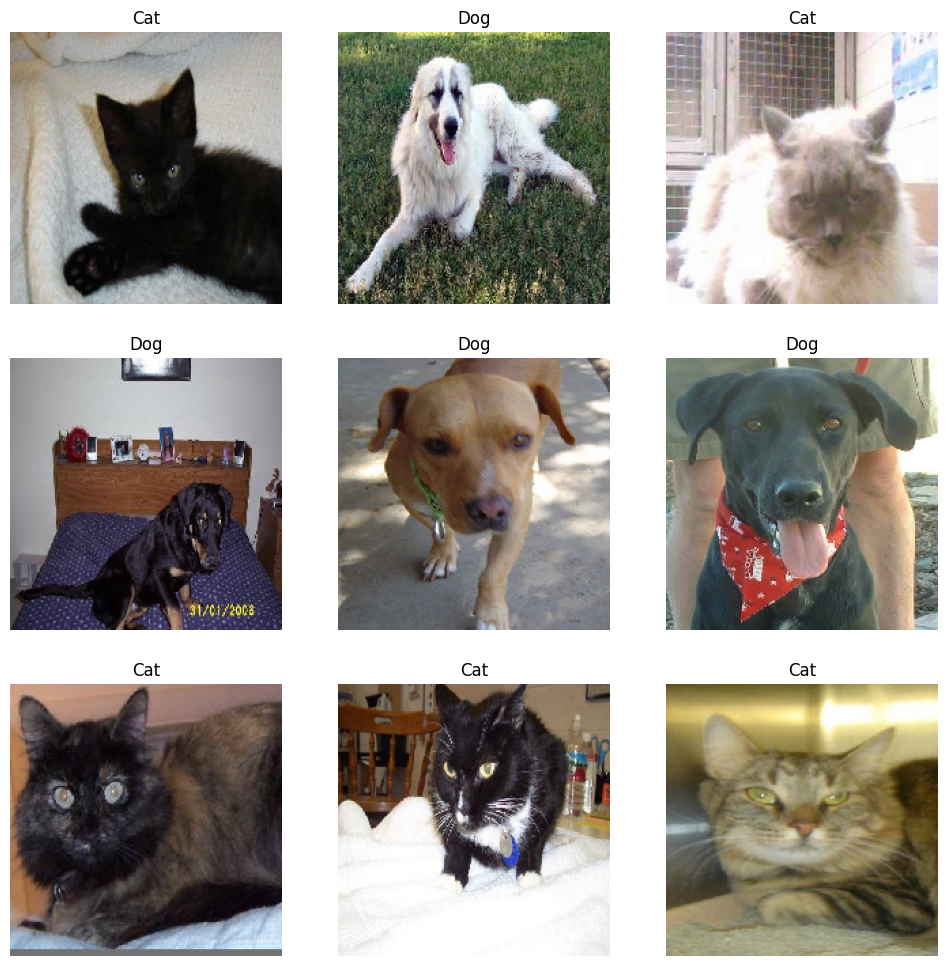

In [12]:
# Obtener un batch del generador de entrenamiento
images, labels = next(trdata)

plt.figure(figsize=(12, 12))

for i in range(9):  # mostrar 9 imágenes
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.show()

In [ ]:
# Modelo CNN

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    MaxPool2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

2025-11-21 09:50:47.560532: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
# Compilación del modelo

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,894,017 (72.07 MB)

 Trainable params: 18,894,017 (72.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    trdata,
    validation_data=valdata,
    epochs=6
)

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 349s 693ms/step - accuracy: 0.6187 - loss: 0.6781 - val_accuracy: 0.6957 - val_loss: 0.5799
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 384s 698ms/step - accuracy: 0.7462 - loss: 0.5178 - val_accuracy: 0.7455 - val_loss: 0.5178
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 341s 681ms/step - accuracy: 0.8282 - loss: 0.3849 - val_accuracy: 0.7670 - val_loss: 0.5152
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 342s 685ms/step - accuracy: 0.9166 - loss: 0.2081 - val_accuracy: 0.7490 - val_loss: 0.6677
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 344s 687ms/step - accuracy: 0.9769 - loss: 0.0684 - val_accuracy: 0.7380 - val_loss: 1.0211
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 342s 684ms/step - accuracy: 0.9926 - loss: 0.0298 - val_accuracy: 0.7620 - val_loss: 1.1398


**Conclusión del modelo 1:** El modelo muestra un overfitting claro. El accuracy en train alcanza muy rápido valores de 0.99, mientras que el validation accuracy permanece en 0.76. Esto indica que el modelo está aprendiendo demasiado los patrones del train y no generaliza bien los datos nuevos. Esto se empieza a observar ya en las epochs 3-4, donde el modelo dejó de aprender de forma útil y comienza a sobreajustarse.

Probaré un entrenamiento más controlado utilizando EarlyStopping y ModelCheckpoint para detener el entrenamiento antes de que aparezca el overfitting y guardar automáticamente el mejor modelo obtenido durante el proceso.

In [ ]:


checkpoint = ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,          # nº de épocas sin mejorar antes de parar
    restore_best_weights=True,
    mode="min",
    verbose=1
)

In [12]:
history = model.fit(
    trdata,
    epochs=50,                   
    validation_data=valdata,
    callbacks=[checkpoint, early_stop]  
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9947 - loss: 0.0220
Epoch 1: val_loss improved from None to 1.19743, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 341s 683ms/step - accuracy: 0.9920 - loss: 0.0297 - val_accuracy: 0.7540 - val_loss: 1.1974
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.9953 - loss: 0.0169
Epoch 2: val_loss did not improve from 1.19743
500/500 ━━━━━━━━━━━━━━━━━━━━ 380s 678ms/step - accuracy: 0.9936 - loss: 0.0221 - val_accuracy: 0.7567 - val_loss: 1.2210
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.9978 - loss: 0.0088
Epoch 3: val_loss did not improve from 1.19743
500/500 ━━━━━━━━━━━━━━━━━━━━ 386s 686ms/step - accuracy: 0.9977 - loss: 0.0085 - val_accuracy: 0.7607 - val_loss: 1.4080
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9991 - loss: 0.0032
Epoch 4: val_loss did not improve from 1.19743
500/500 ━━━━━━━━━━━━━━━━━━━━ 339s 677ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.7563 - val_loss: 1.7402
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


**Conclusión modelo 2:** En este modelo incluí EarlyStopping y ModelCheckpoint para intentar reducir el overfitting del modelo anterior. Los resultados muestran que el modelo sigue sobreajustándose: el accuracy vuelve a subir casi inmediatamente a 0.99 desde la primera epoch, mientras que val_accuracy se mantiene en 0.75. Se detuvo el entremamiento en epoch 4 ya que desde la epoch 1 no estaba mejorando.

En el siguiente paso incorporaré regularización como Data Augmentation (aumentar la diversidad del train y evitar que memorice los mismos ejemplos) y Dropout (desactivar neuronas para evitar que memorice)



In [ ]:
# Añadimos data augmentation para mejorar el modelo

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
trdata = train_datagen.flow_from_directory(
    train_path,
    target_size=(200, 200),  
    batch_size=32,
    class_mode="binary",
    subset="training"
)

valdata =train_datagen.flow_from_directory(
    train_path,
    target_size=(200,200),
    batch_size=32,
    class_mode="binary",
    subset="validation"
    
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [17]:
# Añadimos Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    MaxPool2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    trdata,
    epochs=50,                   
    validation_data=valdata,
    callbacks=[checkpoint, early_stop]  
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.5646 - loss: 0.8191
Epoch 1: val_loss improved from 1.19743 to 0.62849, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 441s 879ms/step - accuracy: 0.5926 - loss: 0.6990 - val_accuracy: 0.6587 - val_loss: 0.6285
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.6389 - loss: 0.6419
Epoch 2: val_loss improved from 0.62849 to 0.58886, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 437s 868ms/step - accuracy: 0.6471 - loss: 0.6344 - val_accuracy: 0.6982 - val_loss: 0.5889
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.6797 - loss: 0.6052
Epoch 3: val_loss improved from 0.58886 to 0.58382, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 441s 881ms/step - accuracy: 0.6877 - loss: 0.5956 - val_accuracy: 0.7092 - val_loss: 0.5838
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.7066 - loss: 0.5695
Epoch 4: val_loss improved from 0.58382 to 0.52494, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 438s 875ms/step - accuracy: 0.7186 - loss: 0.5552 - val_accuracy: 0.7473 - val_loss: 0.5249
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.7414 - loss: 0.5214
Epoch 5: val_loss improved from 0.52494 to 0.49280, saving model to best_model.h5


...

500/500 ━━━━━━━━━━━━━━━━━━━━ 435s 870ms/step - accuracy: 0.7944 - loss: 0.4395 - val_accuracy: 0.8117 - val_loss: 0.4242
Epoch 14/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.7998 - loss: 0.4262
Epoch 14: val_loss did not improve from 0.42417
500/500 ━━━━━━━━━━━━━━━━━━━━ 436s 871ms/step - accuracy: 0.8011 - loss: 0.4287 - val_accuracy: 0.7993 - val_loss: 0.4503
Epoch 15/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8021 - loss: 0.4292
Epoch 15: val_loss improved from 0.42417 to 0.42241, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 433s 865ms/step - accuracy: 0.8044 - loss: 0.4287 - val_accuracy: 0.8008 - val_loss: 0.4224
Epoch 16/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.8078 - loss: 0.4150
Epoch 16: val_loss did not improve from 0.42241
500/500 ━━━━━━━━━━━━━━━━━━━━ 436s 871ms/step - accuracy: 0.8046 - loss: 0.4192 - val_accuracy: 0.7975 - val_loss: 0.4403
Epoch 17/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8039 - loss: 0.4243
Epoch 17: val_loss improved from 0.42241 to 0.40780, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 436s 860ms/step - accuracy: 0.8073 - loss: 0.4195 - val_accuracy: 0.8152 - val_loss: 0.4078
Epoch 18/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8131 - loss: 0.4098
Epoch 18: val_loss did not improve from 0.40780
500/500 ━━━━━━━━━━━━━━━━━━━━ 436s 848ms/step - accuracy: 0.8118 - loss: 0.4127 - val_accuracy: 0.8148 - val_loss: 0.4249
Epoch 19/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.8147 - loss: 0.4094
Epoch 19: val_loss did not improve from 0.40780
500/500 ━━━━━━━━━━━━━━━━━━━━ 438s 876ms/step - accuracy: 0.8164 - loss: 0.4120 - val_accuracy: 0.8138 - val_loss: 0.4143
Epoch 20/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.8155 - loss: 0.3997
Epoch 20: val_loss improved from 0.40780 to 0.40263, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 438s 876ms/step - accuracy: 0.8104 - loss: 0.4091 - val_accuracy: 0.8217 - val_loss: 0.4026
Epoch 21/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.8179 - loss: 0.4029
Epoch 21: val_loss improved from 0.40263 to 0.39738, saving model to best_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 442s 876ms/step - accuracy: 0.8189 - loss: 0.4018 - val_accuracy: 0.8225 - val_loss: 0.3974
Epoch 22/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.8177 - loss: 0.4002
Epoch 22: val_loss did not improve from 0.39738
500/500 ━━━━━━━━━━━━━━━━━━━━ 435s 870ms/step - accuracy: 0.8213 - loss: 0.3968 - val_accuracy: 0.8198 - val_loss: 0.4042
Epoch 23/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8268 - loss: 0.3879
Epoch 23: val_loss did not improve from 0.39738
500/500 ━━━━━━━━━━━━━━━━━━━━ 439s 865ms/step - accuracy: 0.8238 - loss: 0.3903 - val_accuracy: 0.8183 - val_loss: 0.4017
Epoch 24/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.8276 - loss: 0.3920
Epoch 24: val_loss did not improve from 0.39738
500/500 ━━━━━━━━━━━━━━━━━━━━ 429s 858ms/step - accuracy: 0.8271 - loss: 0.3930 - val_accuracy: 0.8223 - val_loss: 0.3975
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 21.


**Conclusión modelo 3:** Este modelo muestra una mejora progresiva en accuracy y en val_accuracy. Comenzó el entrenamiento con un accuracy bajo (56 %), pero el modelo fue aprendiendo de forma progresiva hasta alcanzar valores de 82 % en accuracy y en val_accuracy. En el apoch 21 fue donde se activó early stopping.
Me quedaré con este modelo por mostrar un buen rendimiento, buena capacidad de generalización (val_accuracy = 82%) y un comportamiento coherente durante el entrenamiento.
A continuación probaremos su capacidad de predecir el conjunto de datos del test.

In [3]:
model = load_model("best_model.h5")

2025-11-22 18:56:28.993965: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [5]:
test_loss, test_accuracy = model.evaluate(tsdata)
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.8416 - loss: 0.3697
Test accuracy: 0.8416000008583069
Test loss: 0.3697025775909424


Los resultados obtenidos de la predicción del test son buenos y coherentes con el rendimiento observado durante el entrenamiento, confirmando que el modelo generaliza bien y no está sobreajustado

In [4]:
# Guardar el modelo
with open("../models/CNN_21epoch_daugmentation_dropout.sav", "wb") as f:
    pickle.dump(model, f)